**<h2> Cleaning & Analyzing the Dataset </h2>**

In [223]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler

data = pd.read_csv(r"Titanic-Dataset.csv") #Reading the dataset from the CSV file

print(data.head())
print()
print(data.columns)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

I

In [224]:
print(data.dtypes) #Checking the data types of each column in the dataset

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [225]:
print(data.shape)

(891, 12)


In [226]:
print(data.describe)

<bound method NDFrame.describe of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                 

In [227]:
print(data.isnull().sum()) #Checking for null values in the dataset

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [228]:
print( data.duplicated().sum()) #Checking for duplicate values in the dataset)

0


<Axes: >

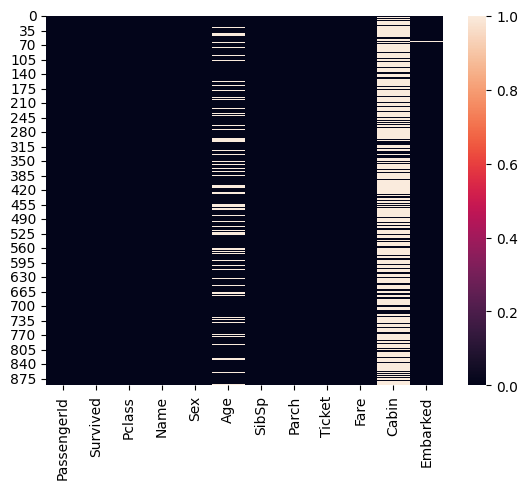

In [229]:
#Chechking Null Values using Vizualization

sns.heatmap(data.isnull())

In [230]:
# Age column inspection.
print("Age: ")
print("Mean",round(data["Age"].mean())) #Rounding because of Float value
print("Meadian: ",data["Age"].median)
print("Max: ",data["Age"].max())
print("Min: ",data["Age"].min())

Age: 
Mean 30
Meadian:  <bound method Series.median of 0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64>
Max:  80.0
Min:  0.42


In [231]:
#Filling with Runded mean value

rounded_Age_mean = round(data["Age"].mean())

data["Age"] = data["Age"].fillna(rounded_Age_mean)

print(data["Age"].isnull().sum())

0


In [232]:
# Cabin column inspection.
print("Cabin: ")
print(data["Cabin"].unique())


Cabin: 
[nan 'C85' 'C123' 'E46' 'G6' 'C103' 'D56' 'A6' 'C23 C25 C27' 'B78' 'D33'
 'B30' 'C52' 'B28' 'C83' 'F33' 'F G73' 'E31' 'A5' 'D10 D12' 'D26' 'C110'
 'B58 B60' 'E101' 'F E69' 'D47' 'B86' 'F2' 'C2' 'E33' 'B19' 'A7' 'C49'
 'F4' 'A32' 'B4' 'B80' 'A31' 'D36' 'D15' 'C93' 'C78' 'D35' 'C87' 'B77'
 'E67' 'B94' 'C125' 'C99' 'C118' 'D7' 'A19' 'B49' 'D' 'C22 C26' 'C106'
 'C65' 'E36' 'C54' 'B57 B59 B63 B66' 'C7' 'E34' 'C32' 'B18' 'C124' 'C91'
 'E40' 'T' 'C128' 'D37' 'B35' 'E50' 'C82' 'B96 B98' 'E10' 'E44' 'A34'
 'C104' 'C111' 'C92' 'E38' 'D21' 'E12' 'E63' 'A14' 'B37' 'C30' 'D20' 'B79'
 'E25' 'D46' 'B73' 'C95' 'B38' 'B39' 'B22' 'C86' 'C70' 'A16' 'C101' 'C68'
 'A10' 'E68' 'B41' 'A20' 'D19' 'D50' 'D9' 'A23' 'B50' 'A26' 'D48' 'E58'
 'C126' 'B71' 'B51 B53 B55' 'D49' 'B5' 'B20' 'F G63' 'C62 C64' 'E24' 'C90'
 'C45' 'E8' 'B101' 'D45' 'C46' 'D30' 'E121' 'D11' 'E77' 'F38' 'B3' 'D6'
 'B82 B84' 'D17' 'A36' 'B102' 'B69' 'E49' 'C47' 'D28' 'E17' 'A24' 'C50'
 'B42' 'C148']


In [233]:
#drop column cabin
data.drop('Cabin',axis=1,inplace=True)

In [234]:
#Chechking Missing values for column = "Embarked" data and filling

print(data["Embarked"].unique())

data['Embarked'] = data['Embarked'].fillna('Q')

print(data['Embarked'].isnull().sum())

['S' 'C' 'Q' nan]
0


**<h2> Encoding the dataset <h2>**

In [235]:
#seperating numerical col and categorical col


num_cols = data.select_dtypes(include=np.number).columns

cat_cols = data.select_dtypes(include="object").columns




In [236]:
#Label Encoding the catagorical cols

le = LabelEncoder()

for col in cat_cols:
    data[col] = le.fit_transform(data[col])

print(data.head(5))

   PassengerId  Survived  Pclass  Name  Sex   Age  SibSp  Parch  Ticket  \
0            1         0       3   108    1  22.0      1      0     523   
1            2         1       1   190    0  38.0      1      0     596   
2            3         1       3   353    0  26.0      0      0     669   
3            4         1       1   272    0  35.0      1      0      49   
4            5         0       3    15    1  35.0      0      0     472   

      Fare  Embarked  
0   7.2500         2  
1  71.2833         0  
2   7.9250         2  
3  53.1000         2  
4   8.0500         2  


In [237]:
# Normalizing / Standardizing numerical values

scaler = StandardScaler()

for num in num_cols:
    data[num_cols] = scaler.fit_transform(data[num_cols])

print(data.head(5))

   PassengerId  Survived    Pclass  Name  Sex       Age     SibSp     Parch  \
0    -1.730108 -0.789272  0.827377   108    1 -0.597055  0.432793 -0.473674   
1    -1.726220  1.266990 -1.566107   190    0  0.634162  0.432793 -0.473674   
2    -1.722332  1.266990  0.827377   353    0 -0.289251 -0.474545 -0.473674   
3    -1.718444  1.266990 -1.566107   272    0  0.403309  0.432793 -0.473674   
4    -1.714556 -0.789272  0.827377    15    1  0.403309 -0.474545 -0.473674   

   Ticket      Fare  Embarked  
0     523 -0.502445         2  
1     596  0.786845         0  
2     669 -0.488854         2  
3      49  0.420730         2  
4     472 -0.486337         2  


**<h3>Identifying outliers using Vizualization**

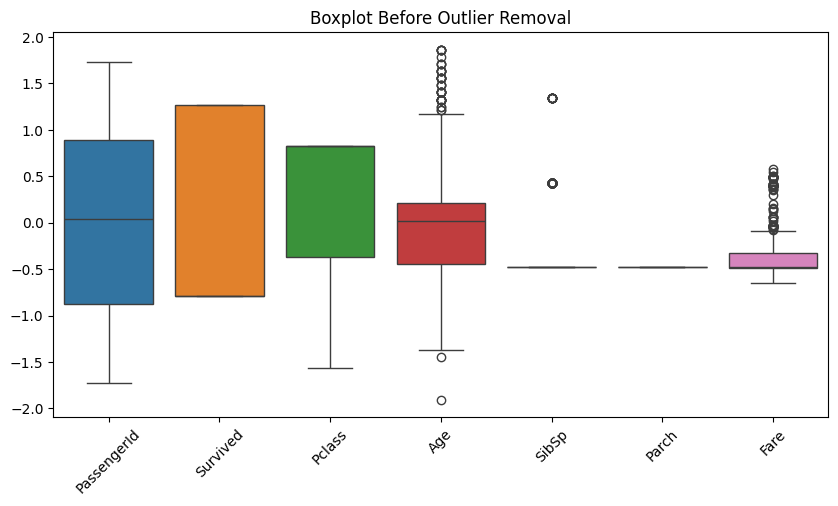

In [241]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=data[num_cols])

plt.title("Boxplot Before Outlier Removal")
plt.xticks(rotation=45)

plt.show()

In [239]:
# Calculate IQR

print("Before Outliers our data: ")
print(data.shape)
Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)

IQR = Q3 - Q1

# Keep only non-outlier rows
condition = ~((data[num_cols] < (Q1 - 1.5 * IQR)) |
              (data[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

data = data[condition]

print("After Outlier data:" )

print(data.shape)


Before Outliers our data: 
(891, 11)
After Outlier data:
(577, 11)


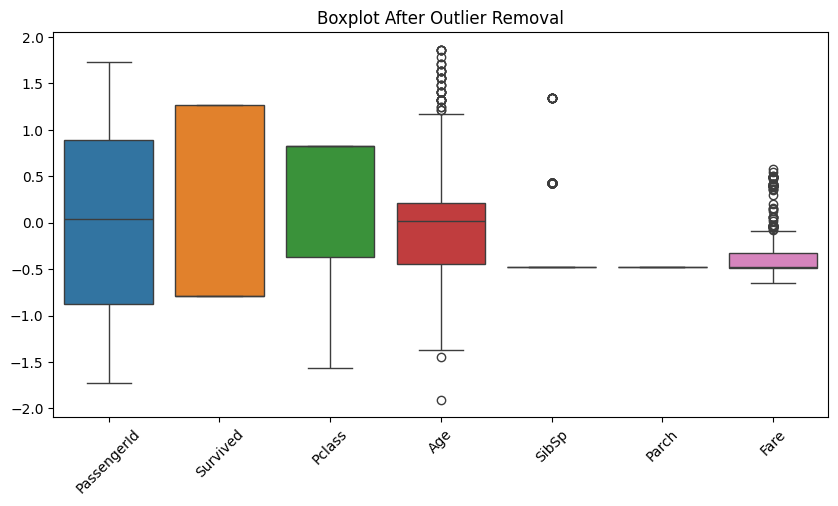

In [242]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=data[num_cols])

plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=45)

plt.show()